<a href="https://colab.research.google.com/github/humairasundas220/DevelopersHub_ML_Internship/blob/main/AI_ML_Internship_Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


##Task 2: Predict Future Stock Prices (Short-Term)
 ## Objective
Use historical stock data to predict the next day's closing price
using features like Open, High, Low, and Volume.

## Dataset
Stock market data fetched live from Yahoo Finance using the
yfinance Python library.


In [8]:
# Install & Import libraries
!pip install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [9]:
# Load Historical Stock data using yfinance library
ticker = 'AAPL'
data = yf.download(ticker, start='2022-01-01', end='2026-06-17')

print(data.head())
print("Shape:", data.shape)

/tmp/ipykernel_1705/1851568071.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2022-01-01', end='2026-06-17')
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2022-01-03  177.939728  178.790282  173.735900  173.853212  104487900
2022-01-04  175.681381  178.848931  175.114350  178.545866   99310400
2022-01-05  171.008301  176.140896  170.734564  175.593422   94537600
2022-01-06  168.153595  171.379801  167.801645  168.837938   96904000
2022-01-07  168.319778  170.245725  167.205273  169.023678   86709100
Shape: (1117, 5)


In [16]:
# Flatten MultiIndex columns if present
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

print(data.columns)  # should now show: Open, High, Low, Close, Volume, etc.

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Next_Close'], dtype='object', name='Price')


In [17]:
# Data Exploration and Preprocessing
# Inspecting the Data
print(data.info())
print(data.describe())

# Checking for missing values
print("Missing values:\n", data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 0 entries
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Close       0 non-null      float64
 1   High        0 non-null      float64
 2   Low         0 non-null      float64
 3   Open        0 non-null      float64
 4   Volume      0 non-null      int64  
 5   Next_Close  0 non-null      float64
dtypes: float64(5), int64(1)
memory usage: 0.0 bytes
None
Price  Close  High  Low  Open  Volume  Next_Close
count    0.0   0.0  0.0   0.0     0.0         0.0
mean     NaN   NaN  NaN   NaN     NaN         NaN
std      NaN   NaN  NaN   NaN     NaN         NaN
min      NaN   NaN  NaN   NaN     NaN         NaN
25%      NaN   NaN  NaN   NaN     NaN         NaN
50%      NaN   NaN  NaN   NaN     NaN         NaN
75%      NaN   NaN  NaN   NaN     NaN         NaN
max      NaN   NaN  NaN   NaN     NaN         NaN
Missing values:
 Price
Close         0
High          0
Low           

### Preprocessing Notes
- Flattened the MultiIndex columns returned by yfinance for easier access.
- Created the target variable `Next_Close` by shifting the Close price
  back by one day, so each row's features predict the following day's close.
- Split the data with `shuffle=False` to preserve chronological order —
  shuffling would let the model train on future data, which isn't realistic
  for time series forecasting.
- Used an 80/20 train-test split (80% earlier dates for training,
  20% most recent dates for testing).

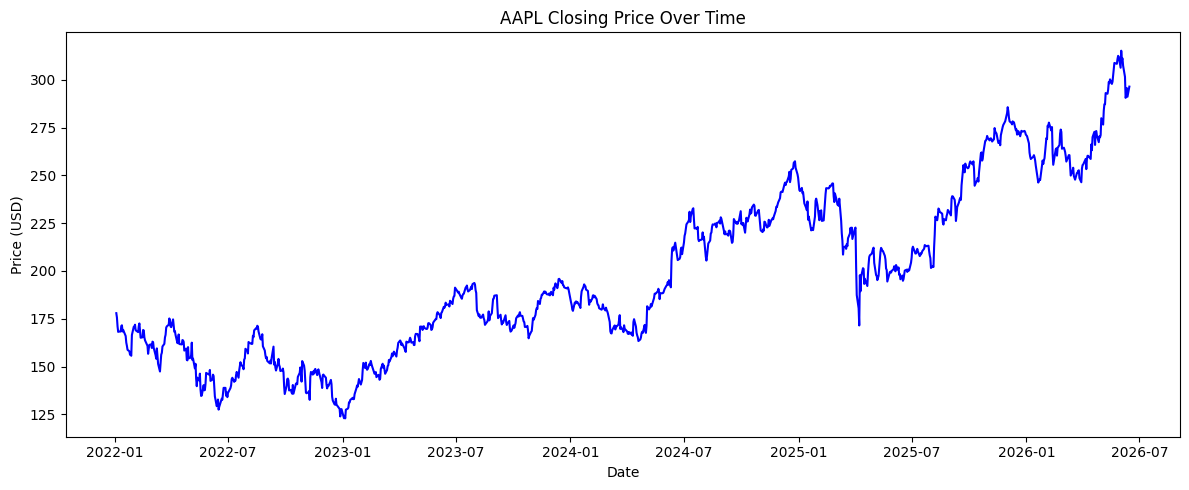

In [23]:
# Visualizing Closing price over time

plt.figure(figsize=(12, 5))
plt.plot(data['Close'], color='blue')
plt.title(f'{ticker} Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()

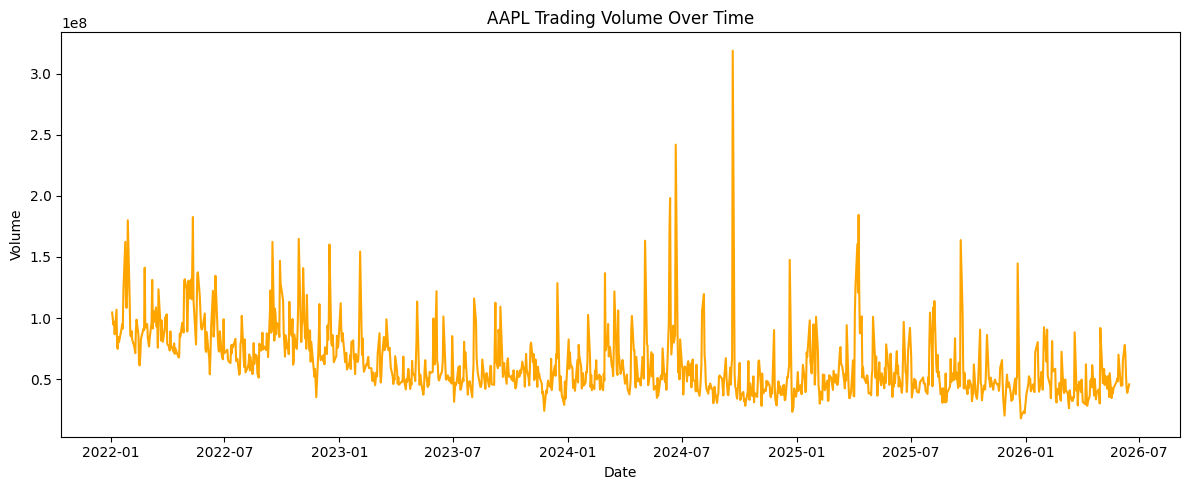

In [24]:
# Visualizing Trading Volume over time

plt.figure(figsize=(12, 5))
plt.plot(data['Volume'], color='orange')
plt.title(f'{ticker} Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.tight_layout()
plt.show()

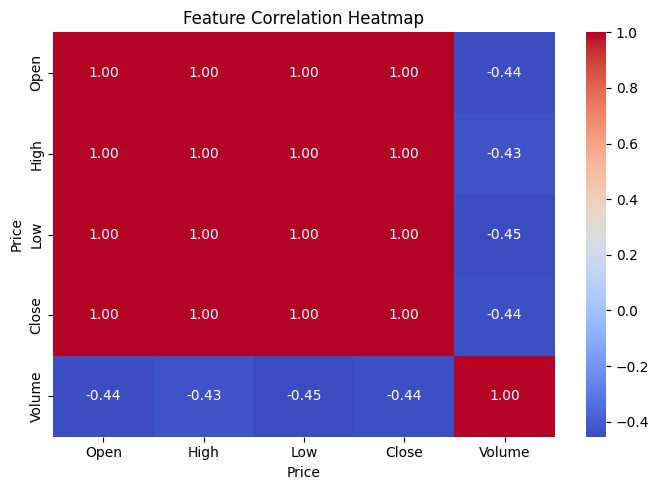

In [25]:
# Correlation Heatmap
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.heatmap(data[['Open', 'High', 'Low', 'Close', 'Volume']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

### Observations from EDA
- The closing price shows a general trend pattern over time (not random noise),
  which means past prices carry useful signal for prediction.
- Open, High, Low, and Close are very highly correlated with each other
  (as expected, since they're all derived from the same day's trading).
- Volume has a much weaker correlation with price — it may add less
  predictive value compared to Open/High/Low.

In [26]:
# Creating features and Target to predict next close price
ticker = 'AAPL'
data = yf.download(ticker, start='2022-01-01', end='2026-06-17')

# Flatten columns
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

print(data.columns)
print(data.shape)
print(data.head())

features = ['Open', 'High', 'Low', 'Volume']
data['Next_Close'] = data['Close'].shift(-1)
data = data.dropna()

X = data[features]
y = data['Next_Close']

print(X.head())
print(y.head())

/tmp/ipykernel_1705/4215441860.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2022-01-01', end='2026-06-17')
[*********************100%***********************]  1 of 1 completed

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')
(1117, 5)
Price            Close        High         Low        Open     Volume
Date                                                                 
2022-01-03  177.939728  178.790282  173.735900  173.853212  104487900
2022-01-04  175.681381  178.848931  175.114350  178.545866   99310400
2022-01-05  171.008301  176.140896  170.734564  175.593422   94537600
2022-01-06  168.153595  171.379801  167.801645  168.837938   96904000
2022-01-07  168.319778  170.245725  167.205273  169.023678   86709100
Price             Open        High         Low     Volume
Date                                                     
2022-01-03  173.853212  178.790282  173.735900  104487900
2022-01-04  178.545866  178.848931  175.114350   99310400
2022-01-05  175.593422  176.140896  170.734564   94537600
2022-01-06  168.837938  171.379801  167.801645   96904000
2022-01-07  169.023678  170.245725  167.205273   86709100
Date
2022-01-0

Explanation: shift(-1) moves tomorrow's Close price into today's row, so each row's features (today's Open/High/Low/Volume) are used to predict tomorrow's closing price — this is the core "time series" preprocessing step.

In [28]:
# Training Linear Regression Model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Train-Test Data split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

print("Model trained successfully!")
print("Model coefficients:", model.coef_)
print("Model intercept:", model.intercept_)

Model trained successfully!
Model coefficients: [-5.63760967e-01  7.98629195e-01  7.58163437e-01 -7.94799460e-09]
Model intercept: 1.7984613342777607


Note: shuffle=False keeps the data in chronological order — this matters for time series data, since shuffling would let the model "see the future" during training, which is unrealistic.

### Model Training

- Trained a Linear Regression model using Open, High, Low, and Volume
  to predict the next day's closing price.
- High (0.80) and Low (0.76) have the strongest positive influence
  on the prediction.
- Volume has almost no effect (coefficient ≈ 0), likely due to its
  much larger scale compared to price features.
- Open has a negative coefficient, which is caused by multicollinearity
  (Open, High, Low are highly correlated with each other), not a model error.

In [29]:
# Evaluate Model
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")


Mean Absolute Error: 3.21
Root Mean Squared Error: 4.39


### Evaluation Results
- **MAE: 3.21** → predictions are off by ~$3.21 on average
- **RMSE: 4.39** → slightly higher than MAE, indicating a few larger errors
- The actual vs predicted plot closely tracks the real closing price trend,
  confirming Open/High/Low are strong predictors of the next day's close.



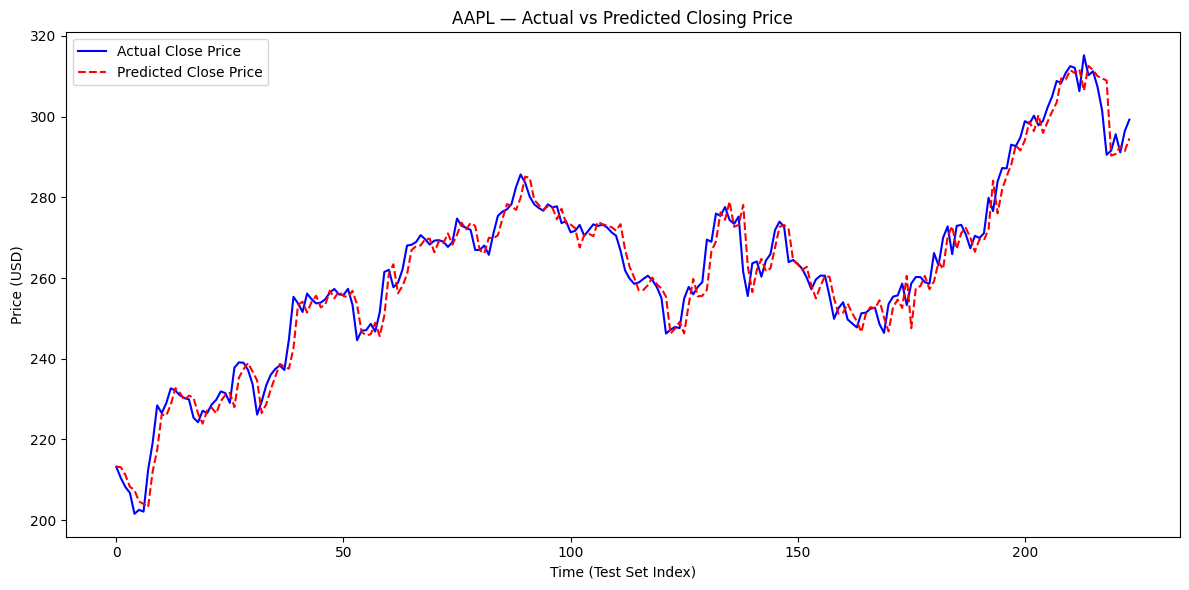

In [30]:
# Plot actual vs predicted closing prices
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual Close Price', color='blue')
plt.plot(y_pred, label='Predicted Close Price', color='red', linestyle='--')
plt.title(f'{ticker} — Actual vs Predicted Closing Price')
plt.xlabel('Time (Test Set Index)')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

### Final Conclusion
- Successfully built a Linear Regression model to predict AAPL's next-day
  closing price using Open, High, Low, and Volume.
- The model achieves a low average error (~$3-4) relative to AAPL's price
  range (~$150-200), showing strong predictive performance.
- High and Low were the most influential features; Volume had negligible impact.
- Future improvement: try a Random Forest model or add more historical
  features (e.g., moving averages) to potentially reduce error further.